# Phase 1 — Shallow EDA
> **Goal:** Understand what the data contains. No thesis at this stage.
>
> Steps: 1.1 Data Quality Audit · 1.2 FK Validation · 1.3 Descriptive Landscape · 1.4 Observations

In [2]:
import sys, warnings
sys.path.append('..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from src.loaders import load_all_tables

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
PALETTE = ['#2563eb', '#16a34a', '#dc2626', '#d97706', '#7c3aed']
FIG_DIR = '../figures/'

tables = load_all_tables()
sales        = tables['sales']
customers    = tables['customers']
orders       = tables['orders']
order_items  = tables['order_items']
products     = tables['products']
promotions   = tables['promotions']
shipments    = tables['shipments']
returns      = tables['returns']
reviews      = tables['reviews']
payments     = tables['payments']
geography    = tables['geography']
inventory    = tables['inventory']
web_traffic  = tables['web_traffic']

print('Tables loaded:', list(tables.keys()))

Tables loaded: ['sales', 'customers', 'orders', 'order_items', 'products', 'promotions', 'shipments', 'returns', 'reviews', 'payments', 'geography', 'inventory', 'web_traffic']


---
## Step 1.1 — Data Quality Audit

In [3]:
def audit_table(name: str, df: pd.DataFrame) -> dict:
    date_cols = [c for c in df.columns if df[c].dtype == 'datetime64[ns]']
    date_range = (
        f"{df[date_cols[0]].min().date()} → {df[date_cols[0]].max().date()}"
        if date_cols else 'N/A'
    )
    missing_pct = df.isna().mean().mul(100).round(1)
    top_missing = (
        missing_pct[missing_pct > 0].sort_values(ascending=False).to_dict()
        if missing_pct.any() else {}
    )
    return {
        'table': name,
        'rows': df.shape[0],
        'cols': df.shape[1],
        'mem_MB': round(df.memory_usage(deep=True).sum() / 1e6, 1),
        'date_range': date_range,
        'missing_cols': len(top_missing),
        'top_missing': str(top_missing)[:80] if top_missing else '—',
        'duplicates': int(df.duplicated().sum()),
    }

audit_rows = [audit_table(name, df) for name, df in tables.items()]
quality = pd.DataFrame(audit_rows)
quality

,table,rows,cols,mem_MB,date_range,missing_cols,top_missing,duplicates
0,sales,3833,3,0.1,2012-07-04 → 2022-12-31,0,—,0
1,customers,121930,7,33.4,2012-01-17 → 2022-12-31,0,—,0
2,orders,646945,8,183.6,2012-07-04 → 2022-12-31,0,—,0
3,order_items,714669,7,78.3,N/A,2,"{'promo_id_2': 100.0, 'promo_id': 61.3}",0
4,products,2412,8,0.8,N/A,0,—,0
5,promotions,50,10,0.0,2013-01-31 → 2022-11-18,1,{'applicable_category': 80.0},0
6,shipments,566067,4,15.9,2012-07-04 → 2022-12-29,0,—,0
7,returns,39939,7,6.7,2012-07-11 → 2022-12-31,0,—,0
8,reviews,113551,7,19.1,2012-07-10 → 2022-12-31,0,—,0
9,payments,646945,4,55.6,N/A,0,—,0


In [4]:
# Per-column missing breakdown for tables with nulls
print('=== Missing value detail ===')
for name, df in tables.items():
    missing = df.isna().mean().mul(100).round(1)
    missing = missing[missing > 0]
    if not missing.empty:
        print(f'\n{name}:')
        print(missing.to_string())

=== Missing value detail ===

order_items:
promo_id       61.3
promo_id_2    100.0

promotions:
applicable_category    80.0


In [5]:
# Numeric summary for key tables
print('--- sales ---')
display(sales.describe().round(2))
print('\n--- orders ---')
display(orders.describe(include='all').T[['count','unique','top','mean','min','max']].dropna(how='all'))

--- sales ---


,Date,Revenue,COGS
count,3833,3833.00,3833.00
mean,2017-10-02 00:00:00,4286584.03,3695134.49
min,2012-07-04 00:00:00,279813.94,236576.31
25%,2015-02-17 00:00:00,2471088.82,2150580.23
50%,2017-10-02 00:00:00,3647303.90,3161112.99
75%,2020-05-17 00:00:00,5350877.20,4637293.92
max,2022-12-31 00:00:00,20905271.35,16535857.67
std,NaN,2624840.20,2219788.77



--- orders ---


,count,unique,top,mean,min,max
order_id,646945.0,NaN,NaN,417189.470332,1.0,834397.0
order_date,646945,NaN,NaN,2016-11-28 05:46:39.463323904,2012-07-04 00:00:00,2022-12-31 00:00:00
customer_id,646945.0,NaN,NaN,84906.203535,1.0,157563.0
zip,646945.0,NaN,NaN,55410.740423,1001.0,99950.0
order_status,646945,6,delivered,NaN,NaN,NaN
payment_method,646945,5,credit_card,NaN,NaN,NaN
device_type,646945,3,mobile,NaN,NaN,NaN
order_source,646945,6,organic_search,NaN,NaN,NaN


In [6]:
# Categorical cardinality
for name, df in tables.items():
    cats = df.select_dtypes('object').nunique()
    if not cats.empty:
        print(f'{name}: {cats.to_dict()}')

customers: {'city': 42, 'gender': 3, 'age_group': 5, 'acquisition_channel': 6}
orders: {'order_status': 6, 'payment_method': 5, 'device_type': 3, 'order_source': 6}
order_items: {'promo_id': 50, 'promo_id_2': 2}
products: {'product_name': 2172, 'category': 4, 'segment': 8, 'size': 4, 'color': 10}
promotions: {'promo_id': 50, 'promo_name': 50, 'promo_type': 2, 'applicable_category': 2, 'promo_channel': 5}
returns: {'return_id': 39939, 'return_reason': 5}
reviews: {'review_id': 113551, 'review_title': 18}
payments: {'payment_method': 5}
geography: {'city': 42, 'region': 3, 'district': 39}
inventory: {'product_name': 1465, 'category': 4, 'segment': 8}
web_traffic: {'traffic_source': 6}


---
## Step 1.2 — Foreign Key Validation

In [7]:
def fk_check(child_name, child_col, parent_name, parent_col, child_df, parent_df):
    child_vals  = set(child_df[child_col].dropna())
    parent_vals = set(parent_df[parent_col].dropna())
    orphans = child_vals - parent_vals
    coverage = 1 - len(orphans) / len(child_vals) if child_vals else 1.0
    print(f"{child_name}.{child_col} → {parent_name}.{parent_col}: "
          f"{coverage*100:.2f}% coverage | orphans: {len(orphans):,}")

fk_check('orders',      'customer_id', 'customers', 'customer_id', orders,     customers)
fk_check('order_items', 'order_id',    'orders',    'order_id',    order_items, orders)
fk_check('order_items', 'product_id',  'products',  'product_id',  order_items, products)
fk_check('orders',      'zip',         'geography', 'zip',         orders,      geography)
fk_check('shipments',   'order_id',    'orders',    'order_id',    shipments,   orders)
fk_check('returns',     'order_id',    'orders',    'order_id',    returns,     orders)
fk_check('reviews',     'order_id',    'orders',    'order_id',    reviews,     orders)
fk_check('payments',    'order_id',    'orders',    'order_id',    payments,    orders)

orders.customer_id → customers.customer_id: 100.00% coverage | orphans: 0
order_items.order_id → orders.order_id: 100.00% coverage | orphans: 0
order_items.product_id → products.product_id: 100.00% coverage | orphans: 0
orders.zip → geography.zip: 100.00% coverage | orphans: 0
shipments.order_id → orders.order_id: 100.00% coverage | orphans: 0
returns.order_id → orders.order_id: 100.00% coverage | orphans: 0
reviews.order_id → orders.order_id: 100.00% coverage | orphans: 0
payments.order_id → orders.order_id: 100.00% coverage | orphans: 0


In [8]:
# Cardinality ratios — what proportion of orders have downstream records?
n_orders = orders['order_id'].nunique()
print(f"Total unique orders : {n_orders:,}")
print(f"  w/ shipment        : {shipments['order_id'].nunique() / n_orders * 100:.1f}%")
print(f"  w/ review          : {reviews['order_id'].nunique()   / n_orders * 100:.1f}%")
print(f"  w/ return          : {returns['order_id'].nunique()   / n_orders * 100:.1f}%")
print(f"  w/ payment         : {payments['order_id'].nunique()  / n_orders * 100:.1f}%")

n_items = order_items['order_id'].nunique()
print(f"\nOrders with line items: {n_items / n_orders * 100:.1f}%")

# Promo penetration
promo_orders = order_items['promo_id'].notna().sum()
total_lines  = len(order_items)
print(f"\nOrder-item lines with a promo_id : {promo_orders / total_lines * 100:.1f}%")

Total unique orders : 646,945
  w/ shipment        : 87.5%
  w/ review          : 17.2%
  w/ return          : 5.6%
  w/ payment         : 100.0%

Orders with line items: 100.0%

Order-item lines with a promo_id : 38.7%


---
## Step 1.3 — Quick Descriptive Landscape
### A. Revenue

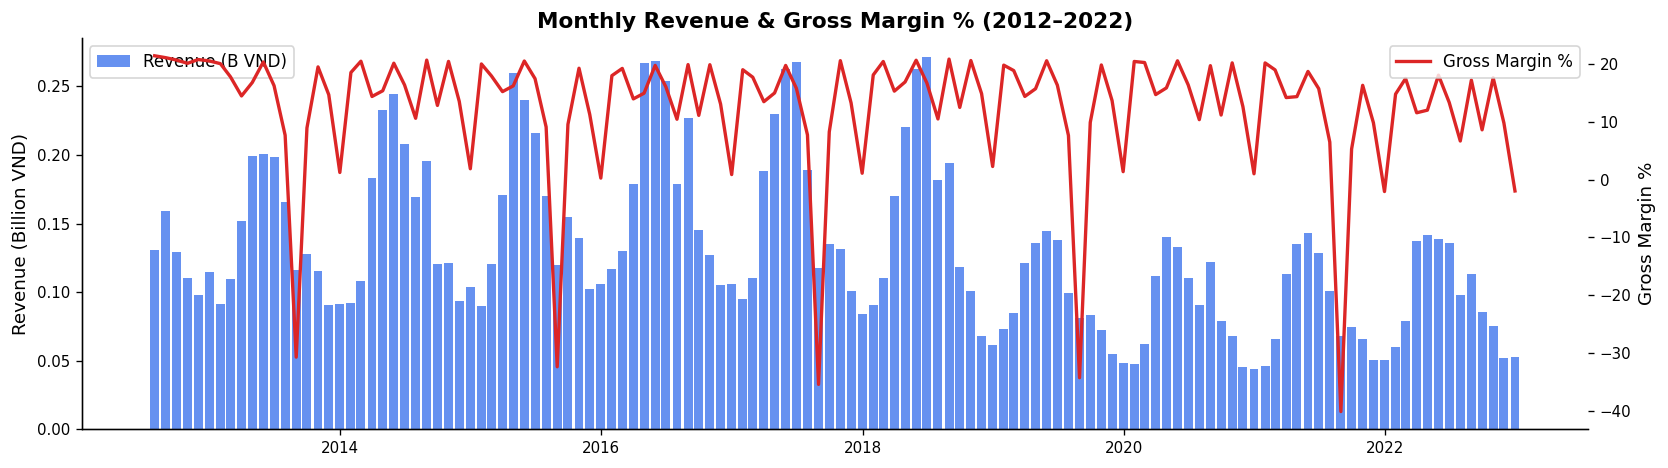

In [9]:
# ── Chart A1: Monthly revenue line chart ──────────────────────────────────────
monthly_rev = sales.resample('ME', on='Date')[['Revenue', 'COGS']].sum()
monthly_rev['Margin%'] = (monthly_rev['Revenue'] - monthly_rev['COGS']) / monthly_rev['Revenue'] * 100

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.bar(monthly_rev.index, monthly_rev['Revenue'] / 1e9, width=25,
        color=PALETTE[0], alpha=0.7, label='Revenue (B VND)')
ax2.plot(monthly_rev.index, monthly_rev['Margin%'], color=PALETTE[2],
         lw=2, label='Gross Margin %')
ax1.set_title('Monthly Revenue & Gross Margin % (2012–2022)')
ax1.set_ylabel('Revenue (Billion VND)')
ax2.set_ylabel('Gross Margin %')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

           Revenue          COGS   GrossProfit  Margin%  YoY_Rev%
Date                                                             
2012  7.414977e+08  5.874619e+08  1.540358e+08    20.77       NaN
2013  1.657169e+09  1.465980e+09  1.911893e+08    11.54    123.49
2014  1.871846e+09  1.574607e+09  2.972384e+08    15.88     12.95
2015  1.889934e+09  1.665442e+09  2.244920e+08    11.88      0.97
2016  2.104641e+09  1.780559e+09  3.240813e+08    15.40     11.36
2017  1.911164e+09  1.694386e+09  2.167785e+08    11.34     -9.19
2018  1.850122e+09  1.542176e+09  3.079467e+08    16.64     -3.19
2019  1.136801e+09  1.005203e+09  1.315986e+08    11.58    -38.56
2020  1.054512e+09  8.860851e+08  1.684271e+08    15.97     -7.24
2021  1.043040e+09  9.411301e+08  1.019097e+08     9.77     -1.09
2022  1.169749e+09  1.020420e+09  1.493287e+08    12.77     12.15


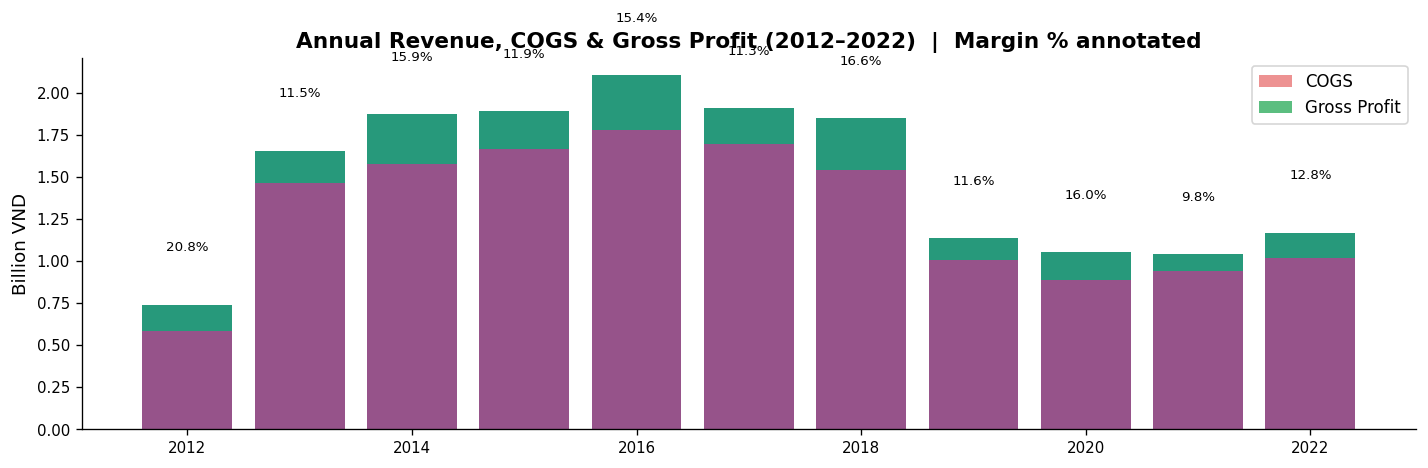

In [10]:
# ── Chart A2: Annual revenue bar chart ────────────────────────────────────────
annual_rev = sales.resample('YE', on='Date')[['Revenue', 'COGS']].sum()
annual_rev.index = annual_rev.index.year
annual_rev['GrossProfit'] = annual_rev['Revenue'] - annual_rev['COGS']
annual_rev['Margin%'] = annual_rev['GrossProfit'] / annual_rev['Revenue'] * 100

# YoY growth
annual_rev['YoY_Rev%'] = annual_rev['Revenue'].pct_change() * 100
print(annual_rev[['Revenue','COGS','GrossProfit','Margin%','YoY_Rev%']].round(2).to_string())

fig, ax = plt.subplots(figsize=(12, 4))
x = annual_rev.index
bars = ax.bar(x, annual_rev['Revenue'] / 1e9, color=PALETTE[0], alpha=0.8)
ax.bar(x, annual_rev['COGS'] / 1e9, color=PALETTE[2], alpha=0.5, label='COGS')
ax.bar(x, annual_rev['GrossProfit'] / 1e9, bottom=annual_rev['COGS'] / 1e9,
       color=PALETTE[1], alpha=0.7, label='Gross Profit')
for i, (yr, row) in enumerate(annual_rev.iterrows()):
    ax.text(yr, row['Revenue'] / 1e9 + 0.3, f"{row['Margin%']:.1f}%",
            ha='center', va='bottom', fontsize=8, color='black')
ax.set_title('Annual Revenue, COGS & Gross Profit (2012–2022)  |  Margin % annotated')
ax.set_ylabel('Billion VND')
ax.legend()
plt.tight_layout()
plt.show()

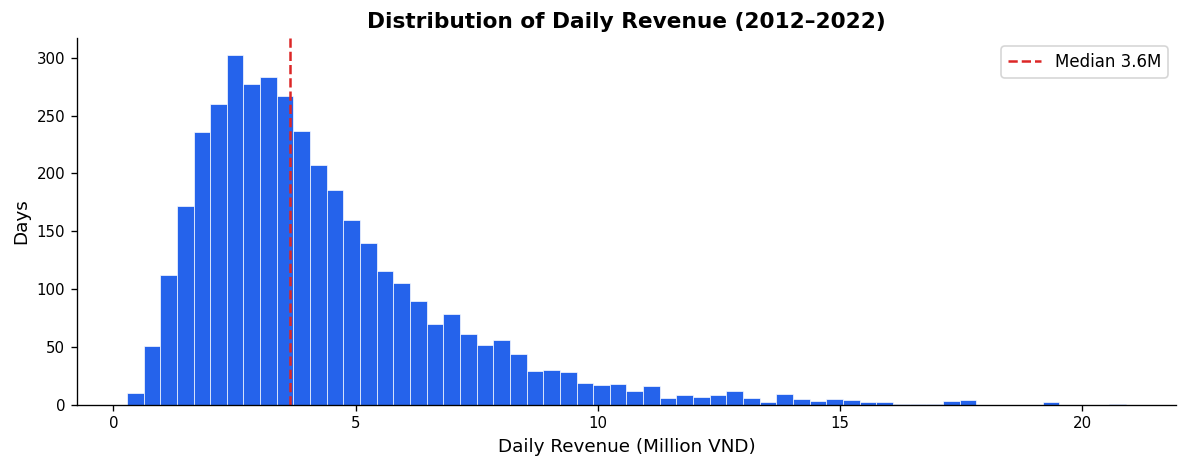

In [11]:
# ── Chart A3: Daily revenue histogram ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sales['Revenue'] / 1e6, bins=60, color=PALETTE[0], edgecolor='white', linewidth=0.4)
ax.set_title('Distribution of Daily Revenue (2012–2022)')
ax.set_xlabel('Daily Revenue (Million VND)')
ax.set_ylabel('Days')
ax.axvline(sales['Revenue'].median() / 1e6, color=PALETTE[2], linestyle='--',
           label=f'Median {sales["Revenue"].median()/1e6:.1f}M')
ax.legend()
plt.tight_layout()
plt.show()

### B. Customers

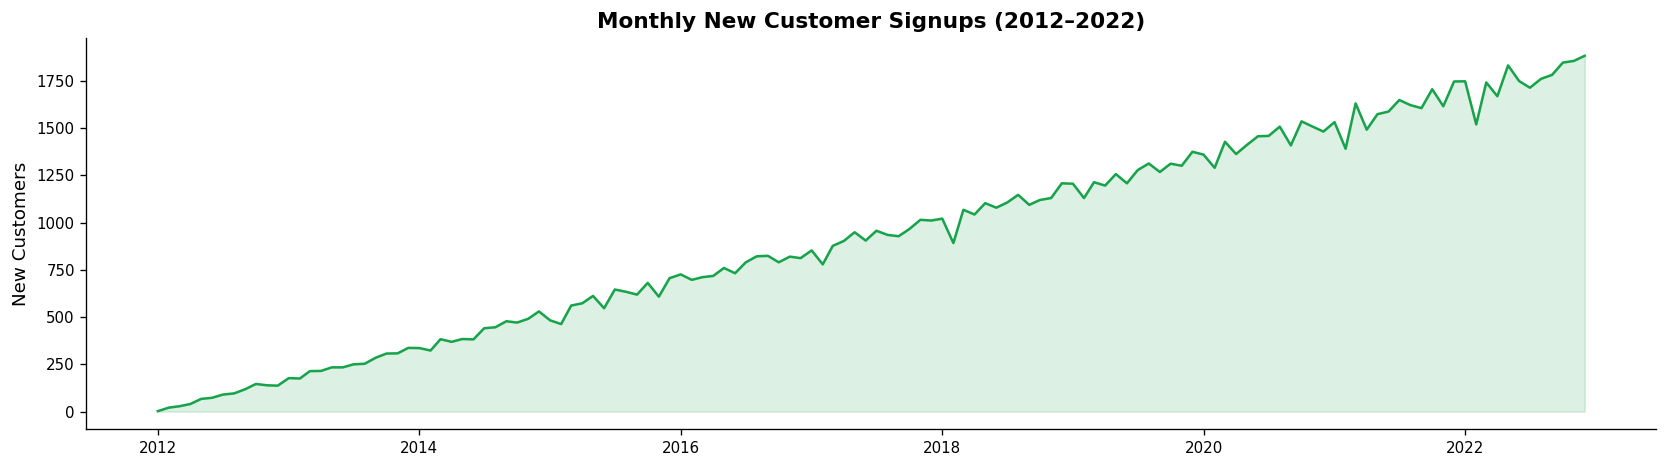

Total customers: 121,930


In [12]:
# ── Chart B1: Monthly new customers ───────────────────────────────────────────
customers['signup_month'] = customers['signup_date'].dt.to_period('M').dt.to_timestamp()
new_cust = customers.groupby('signup_month').size().rename('new_customers')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(new_cust.index, new_cust.values, color=PALETTE[1], lw=1.5)
ax.fill_between(new_cust.index, new_cust.values, alpha=0.15, color=PALETTE[1])
ax.set_title('Monthly New Customer Signups (2012–2022)')
ax.set_ylabel('New Customers')
ax.set_xlabel('')
plt.tight_layout()
plt.show()
print(f'Total customers: {len(customers):,}')

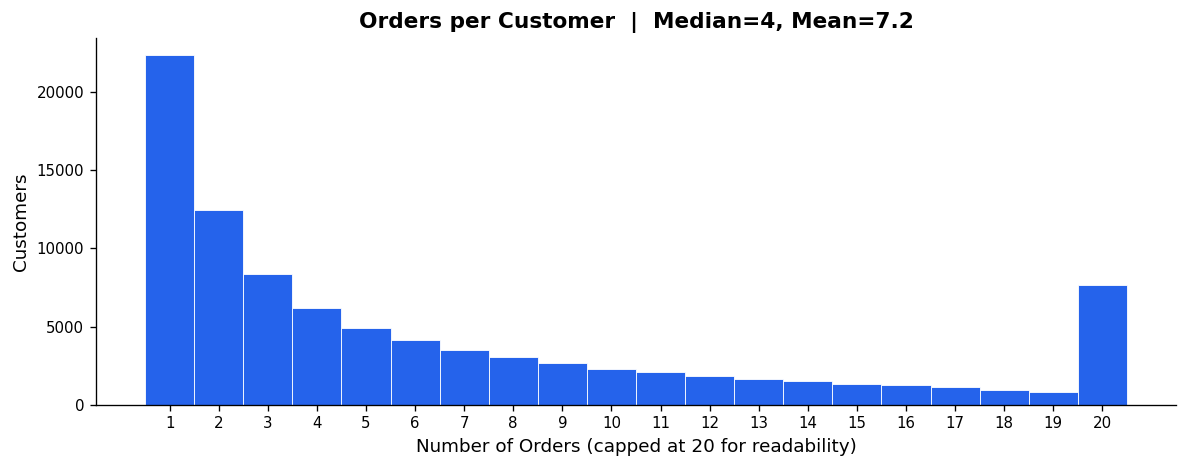

One-time buyers: 24.8%
Repeat (≥2 orders): 75.2%


In [13]:
# ── Chart B2: Orders per customer histogram ────────────────────────────────────
orders_per_cust = orders.groupby('customer_id')['order_id'].count()

fig, ax = plt.subplots(figsize=(10, 4))
vals = orders_per_cust.clip(upper=20)
ax.hist(vals, bins=range(1, 22), color=PALETTE[0], edgecolor='white', linewidth=0.5,
        align='left')
ax.set_title(f'Orders per Customer  |  Median={orders_per_cust.median():.0f}, '
             f'Mean={orders_per_cust.mean():.1f}')
ax.set_xlabel('Number of Orders (capped at 20 for readability)')
ax.set_ylabel('Customers')
ax.set_xticks(range(1, 21))
plt.tight_layout()
plt.show()

one_time = (orders_per_cust == 1).mean() * 100
print(f'One-time buyers: {one_time:.1f}%')
print(f'Repeat (≥2 orders): {100 - one_time:.1f}%')

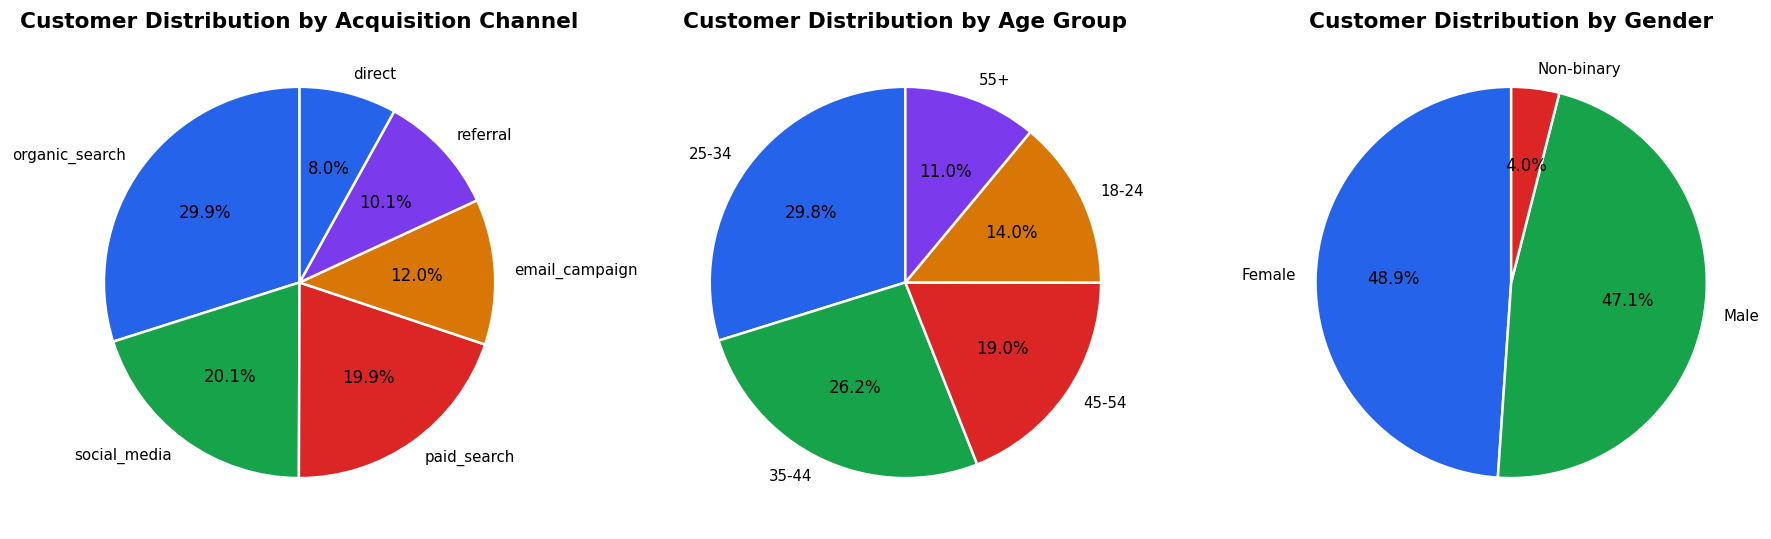

In [14]:
# ── Chart B3: Acquisition channel / Age group / Gender pies ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(
    axes,
    ['acquisition_channel', 'age_group', 'gender'],
    ['Acquisition Channel', 'Age Group', 'Gender'],
):
    counts = customers[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           colors=PALETTE[:len(counts)], startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax.set_title(f'Customer Distribution by {title}')

plt.tight_layout()
plt.show()

### C. Products

In [15]:
# Enrich order_items with product info and revenue
oi_rich = order_items.merge(products[['product_id','product_name','category','segment','price','cogs']],
                            on='product_id', how='left')
oi_rich['line_revenue'] = oi_rich['quantity'] * oi_rich['unit_price'] - oi_rich['discount_amount']
oi_rich['line_profit']  = oi_rich['line_revenue'] - oi_rich['quantity'] * oi_rich['cogs']

print('order_items enriched shape:', oi_rich.shape)

order_items enriched shape: (714669, 14)


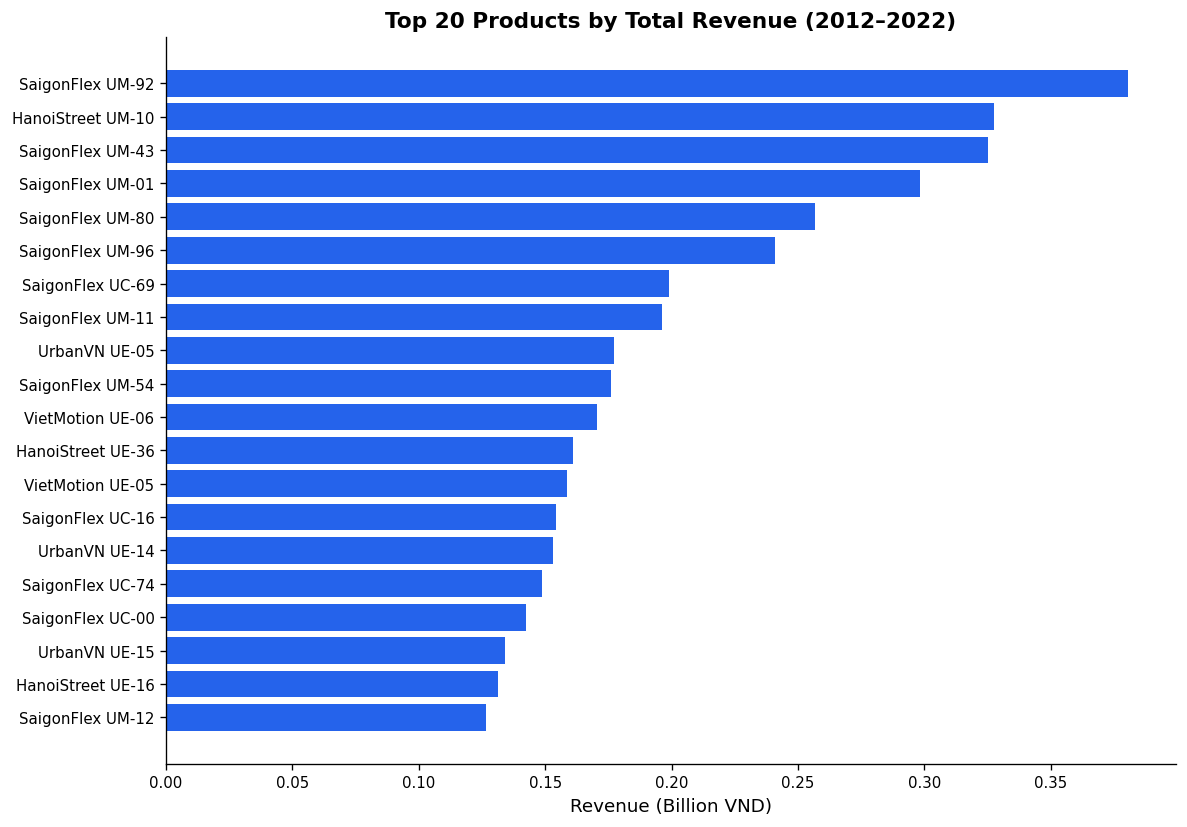

In [16]:
# ── Chart C1: Top 20 products by revenue ──────────────────────────────────────
top_products = (
    oi_rich.groupby('product_name')['line_revenue']
    .sum().nlargest(20).sort_values()
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_products.index, top_products.values / 1e9, color=PALETTE[0])
ax.set_title('Top 20 Products by Total Revenue (2012–2022)')
ax.set_xlabel('Revenue (Billion VND)')
plt.tight_layout()
plt.show()

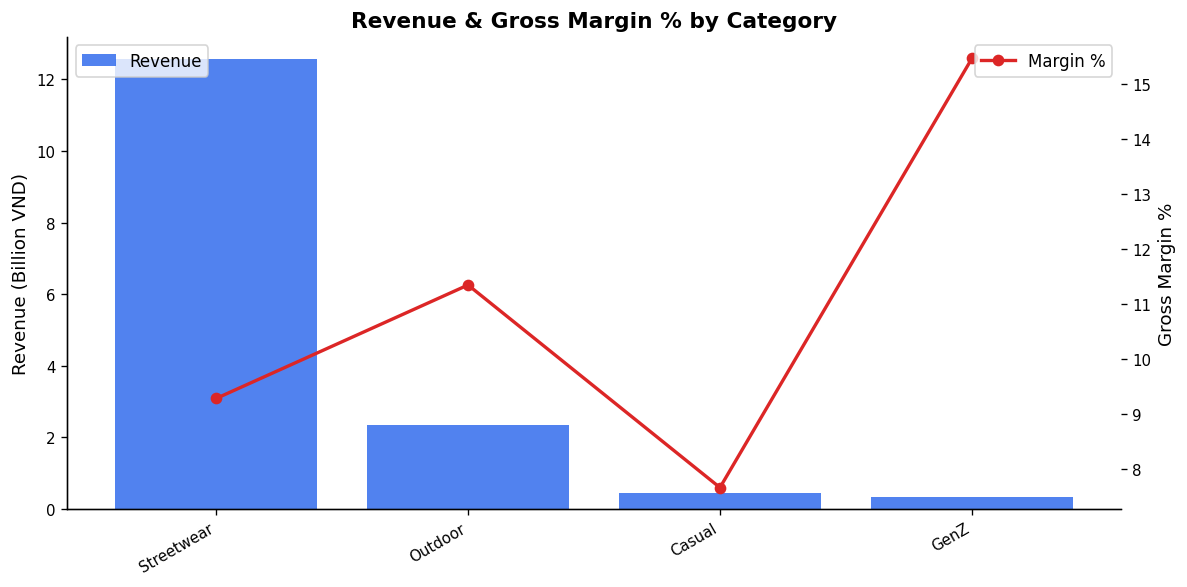

                 revenue        profit  margin
category                                      
Streetwear  1.255848e+10  1.165808e+09    9.28
Outdoor     2.353397e+09  2.670341e+08   11.35
Casual      4.402852e+08  3.374077e+07    7.66
GenZ        3.287102e+08  5.083638e+07   15.47


In [17]:
# ── Chart C2: Revenue & Margin by category ────────────────────────────────────
cat_stats = (
    oi_rich.groupby('category')
    .agg(revenue=('line_revenue', 'sum'), profit=('line_profit', 'sum'))
    .assign(margin=lambda x: x['profit'] / x['revenue'] * 100)
    .sort_values('revenue', ascending=False)
)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
x = range(len(cat_stats))
ax1.bar(x, cat_stats['revenue'] / 1e9, color=PALETTE[0], alpha=0.8, label='Revenue')
ax2.plot(x, cat_stats['margin'], 'o-', color=PALETTE[2], lw=2, label='Margin %')
ax1.set_xticks(list(x))
ax1.set_xticklabels(cat_stats.index, rotation=30, ha='right')
ax1.set_title('Revenue & Gross Margin % by Category')
ax1.set_ylabel('Revenue (Billion VND)')
ax2.set_ylabel('Gross Margin %')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()
print(cat_stats.round(2).to_string())

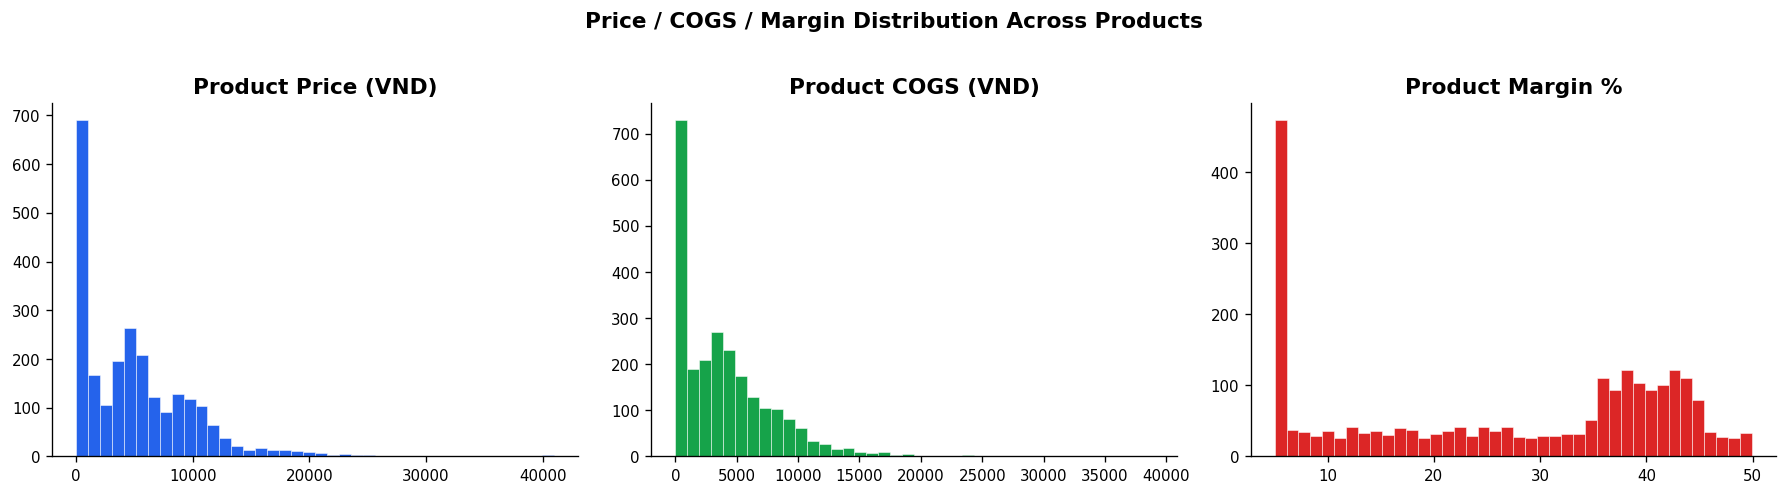

In [18]:
# ── Chart C3: Price, COGS, Margin distributions ────────────────────────────────
products['margin_pct'] = (products['price'] - products['cogs']) / products['price'] * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title, color in zip(
    axes,
    ['price', 'cogs', 'margin_pct'],
    ['Product Price (VND)', 'Product COGS (VND)', 'Product Margin %'],
    PALETTE[:3],
):
    axes[list(axes).index(ax)].hist(products[col], bins=40, color=color, edgecolor='white', lw=0.3)
    ax.set_title(title)

plt.suptitle('Price / COGS / Margin Distribution Across Products', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### C4. Revenue & Gross Margin % by Category — Yearly Trends

In [19]:
# ── Data prep: join order year onto oi_rich ────────────────────────────────────
oi_year = oi_rich.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
oi_year['year'] = oi_year['order_date'].dt.year

cat_year = (
    oi_year
    .groupby(['year', 'category'], as_index=False)
    .agg(revenue=('line_revenue', 'sum'), profit=('line_profit', 'sum'))
)
cat_year['margin'] = cat_year['profit'] / cat_year['revenue'] * 100
print(cat_year.dtypes)
print(cat_year.head(8))

year          int32
category     object
revenue     float64
profit      float64
margin      float64
dtype: object
   year    category       revenue        profit     margin
0  2012      Casual  1.172854e+07  2.174001e+06  18.535996
1  2012        GenZ  9.510543e+06  2.136865e+06  22.468381
2  2012     Outdoor  1.621721e+08  3.507859e+07  21.630471
3  2012  Streetwear  5.580865e+08  1.146464e+08  20.542757
4  2013      Casual  2.778138e+07  3.054813e+06  10.995903
5  2013        GenZ  2.557689e+07  3.599908e+06  14.074846
6  2013     Outdoor  3.059345e+08  2.565742e+07   8.386571
7  2013  Streetwear  1.210872e+09  7.187293e+07   5.935632


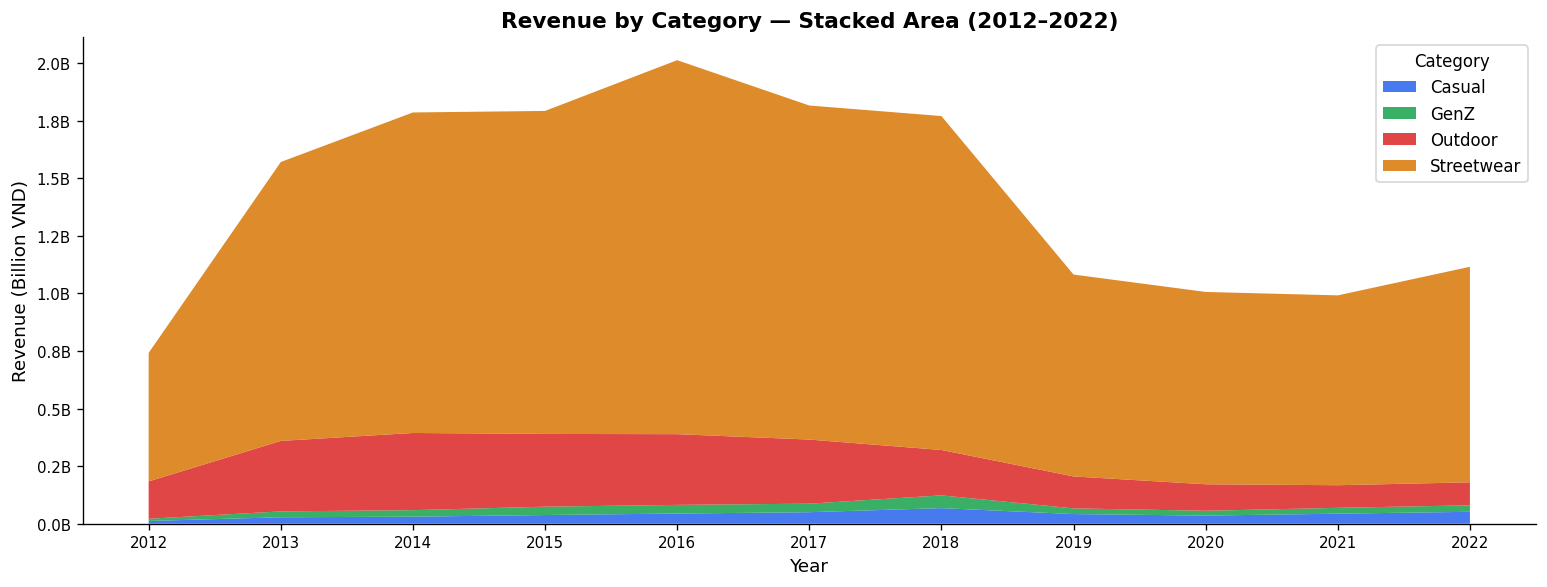

In [20]:
# ── Chart C4a: Stacked Area — Revenue by category per year ────────────────────
rev_pivot = cat_year.pivot(index='year', columns='category', values='revenue').fillna(0) / 1e9
categories = rev_pivot.columns.tolist()
cat_colors = PALETTE[:len(categories)]

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(rev_pivot.index, [rev_pivot[c] for c in categories],
             labels=categories, colors=cat_colors, alpha=0.85)
ax.set_title('Revenue by Category — Stacked Area (2012–2022)')
ax.set_ylabel('Revenue (Billion VND)')
ax.set_xlabel('Year')
ax.set_xticks(rev_pivot.index)
ax.legend(loc='upper right', title='Category')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}B'))
plt.tight_layout()
plt.show()

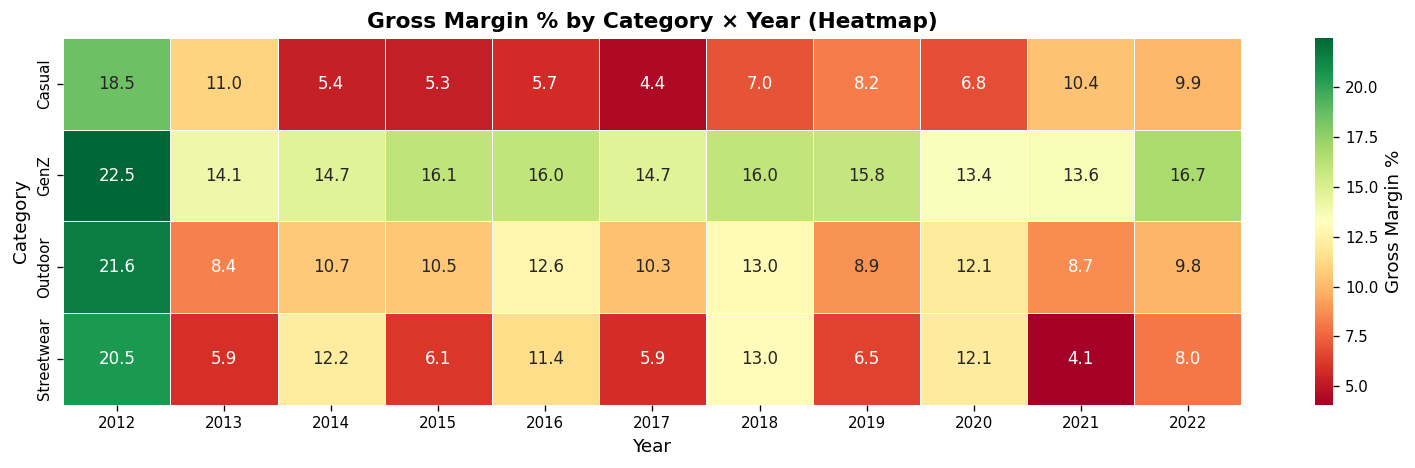

In [21]:
# ── Chart C4b: Heatmap — Gross Margin % by category × year ───────────────────
margin_pivot = cat_year.pivot(index='category', columns='year', values='margin')

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    margin_pivot,
    annot=True, fmt='.1f', cmap='RdYlGn',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Gross Margin %'},
    ax=ax,
)
ax.set_title('Gross Margin % by Category × Year (Heatmap)')
ax.set_xlabel('Year')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

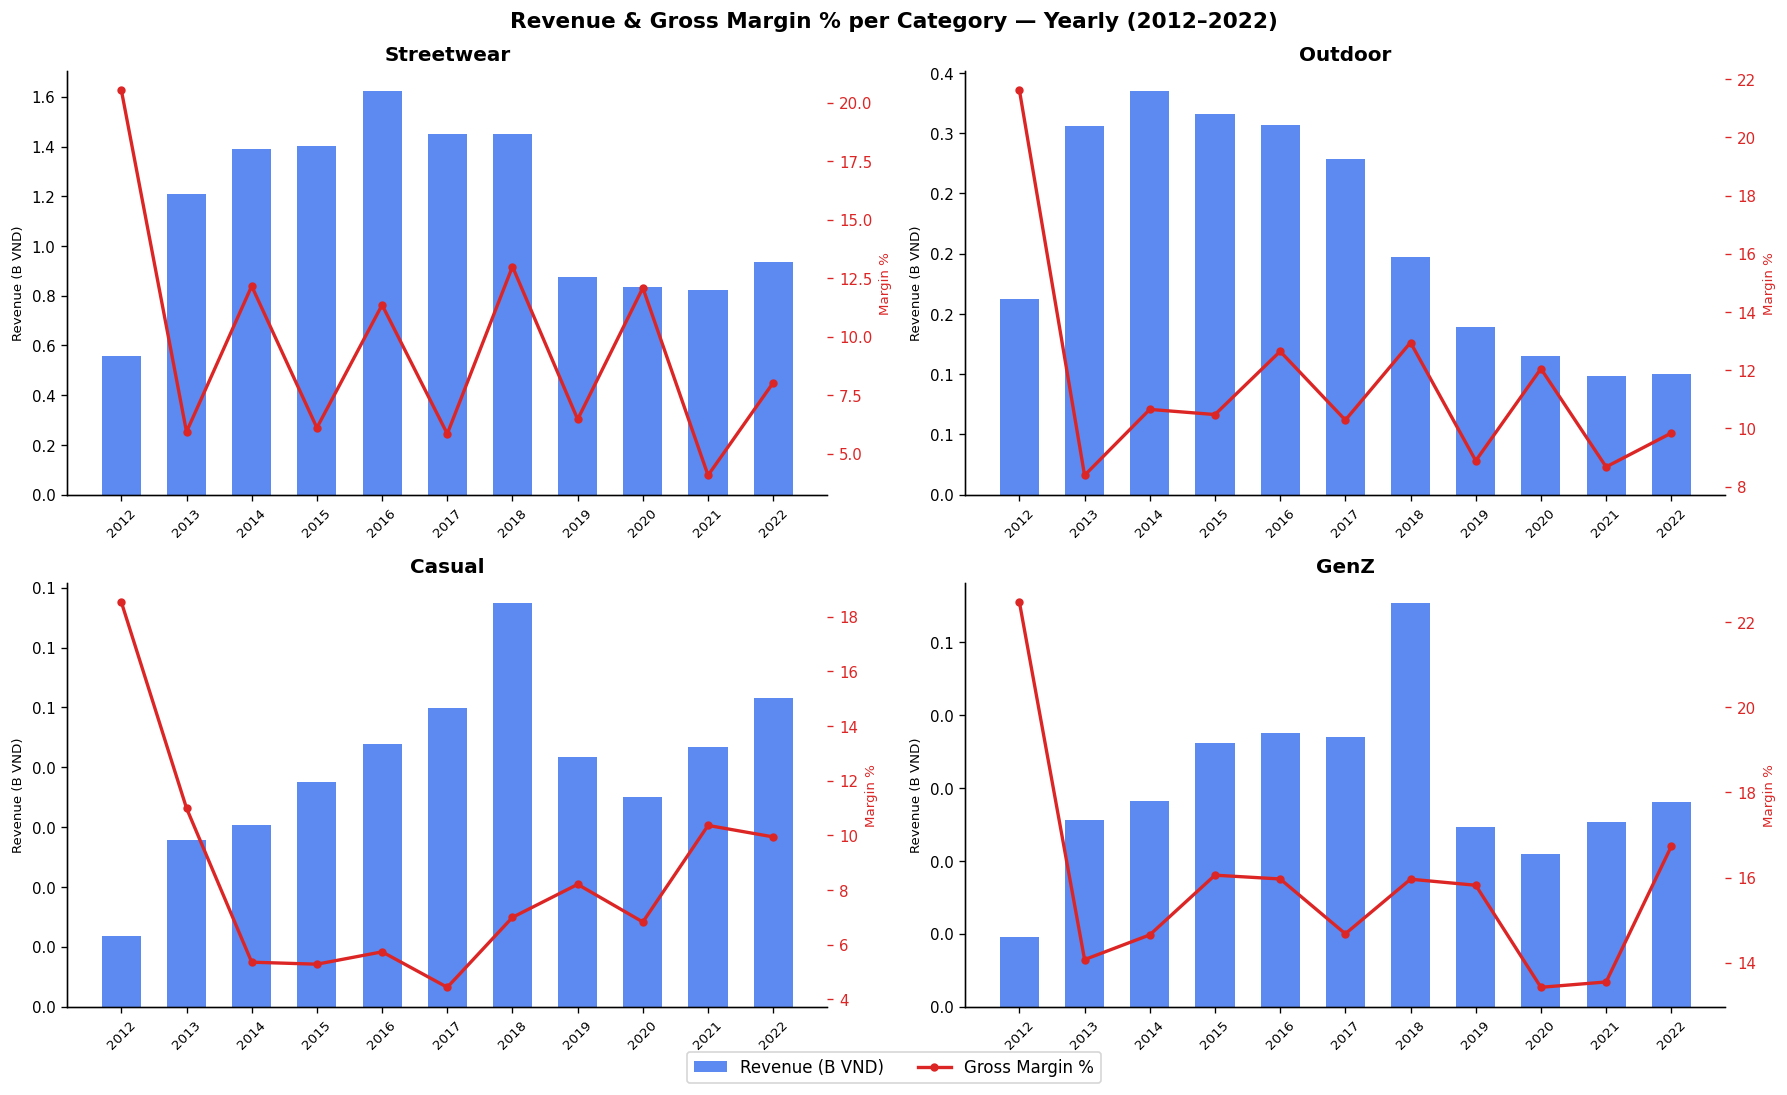

In [22]:
# ── Chart C4c: Small Multiples — Revenue (bar) + Margin % (line) per category ─
cat_totals = (
    cat_year.groupby('category', as_index=False)['revenue']
    .sum()
    .sort_values('revenue', ascending=False)
)
categories_sorted = cat_totals['category'].tolist()
years = sorted(cat_year['year'].unique())

fig, axes = plt.subplots(2, 2, figsize=(15, 9))  # no sharex — conflicts with twinx
axes = axes.flatten()

for ax, cat in zip(axes, categories_sorted):
    df_cat = cat_year[cat_year['category'] == cat].set_index('year').reindex(years)
    ax2 = ax.twinx()

    bars = ax.bar(years, df_cat['revenue'] / 1e9, color=PALETTE[0], alpha=0.75, width=0.6)
    line, = ax2.plot(years, df_cat['margin'], color=PALETTE[2], lw=2, marker='o', ms=4)

    ax.set_title(cat, fontsize=12, fontweight='bold')
    ax.set_ylabel('Revenue (B VND)', fontsize=8)
    ax2.set_ylabel('Margin %', fontsize=8, color=PALETTE[2])
    ax2.tick_params(axis='y', colors=PALETTE[2])
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))

fig.suptitle('Revenue & Gross Margin % per Category — Yearly (2012–2022)',
             fontsize=13, fontweight='bold')
fig.legend([bars, line], ['Revenue (B VND)', 'Gross Margin %'],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

### D. Promotions

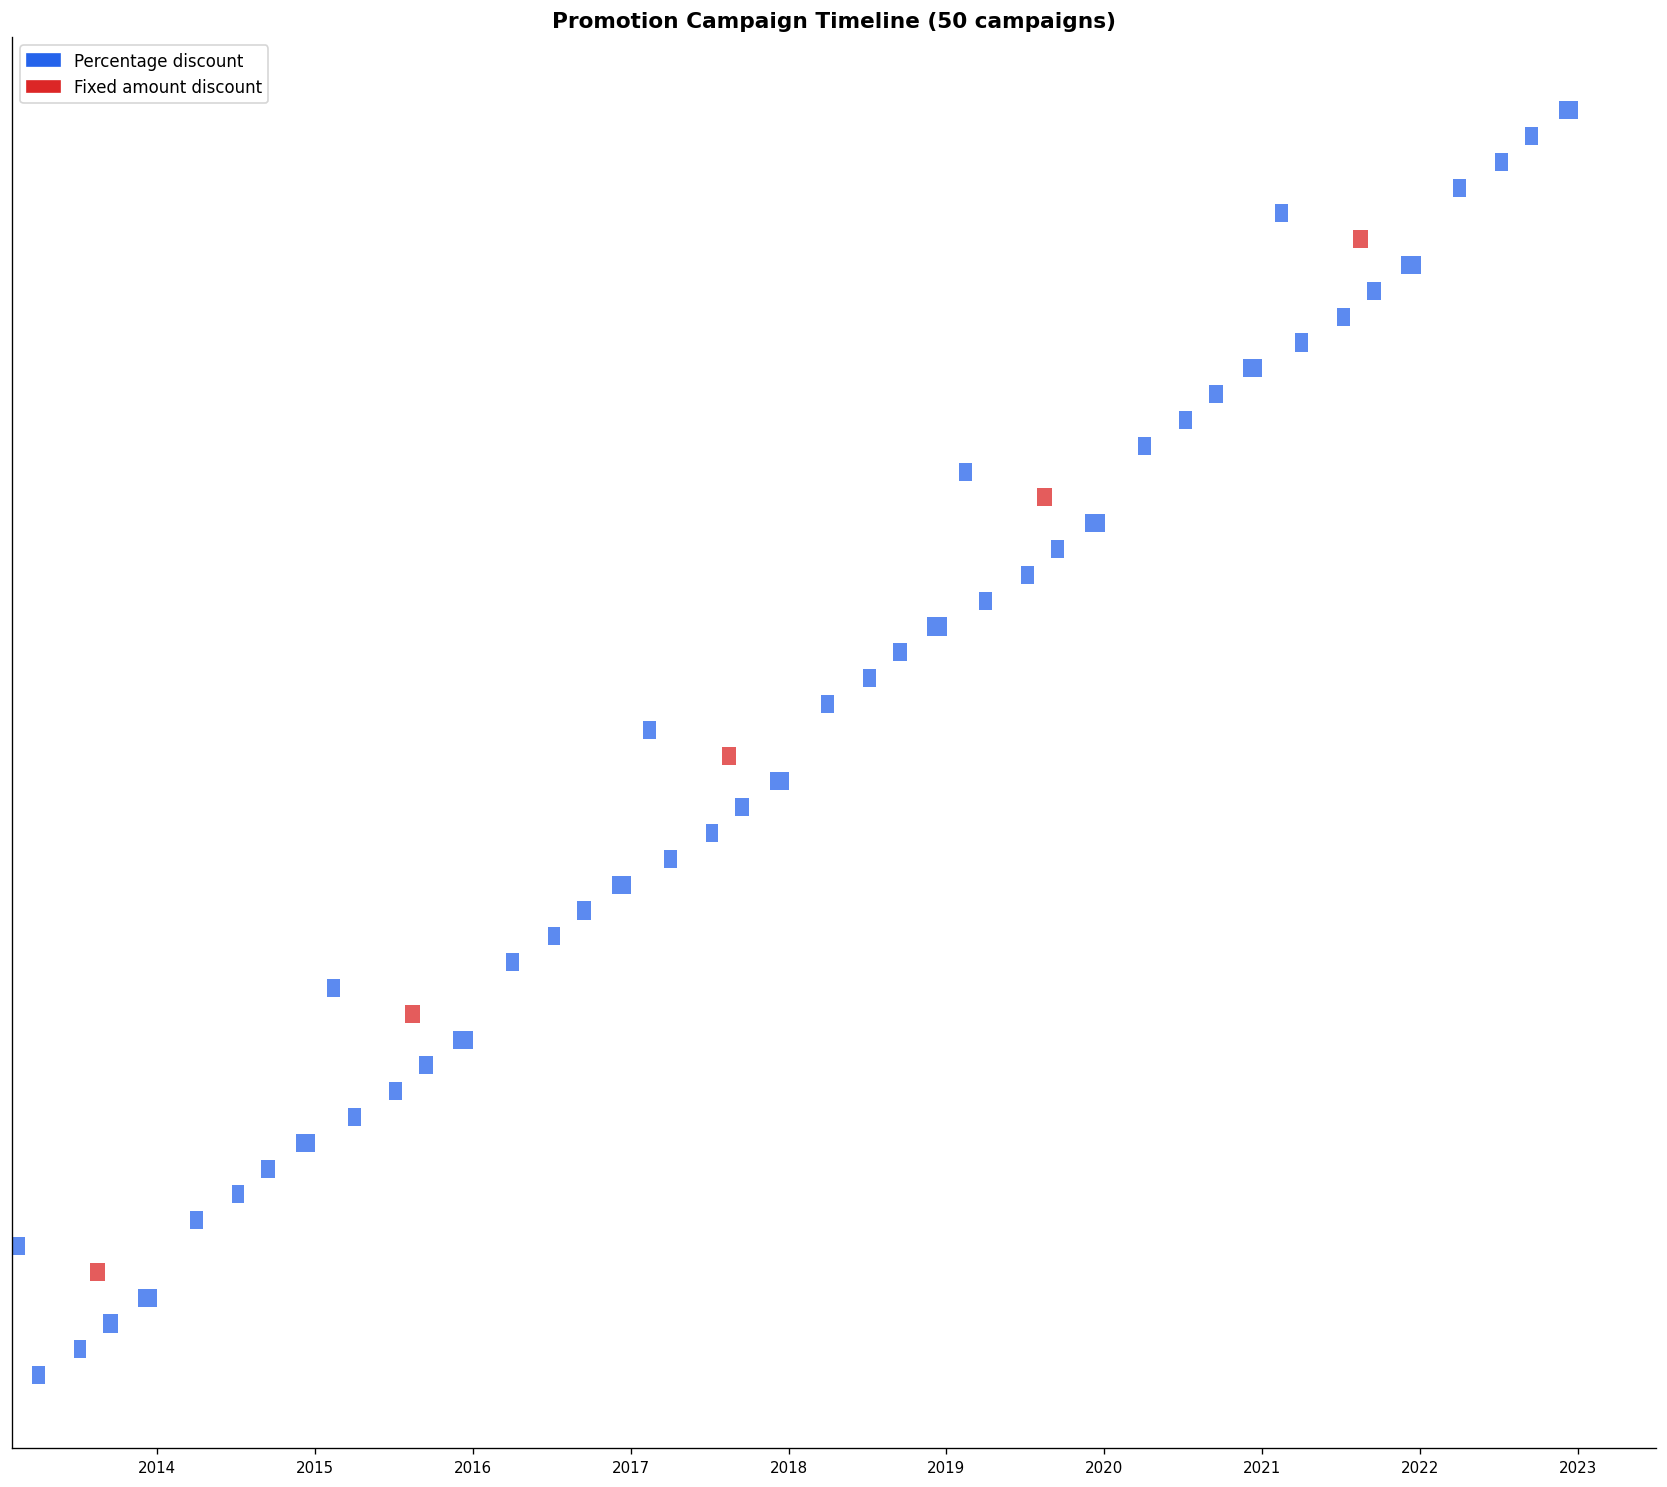

       discount_value  duration
count            50.0      50.0
mean             18.5      33.5
std              11.2       5.8
min              10.0      29.0
25%              12.0      30.0
50%              16.5      30.5
75%              20.0      34.0
max              50.0      45.0


In [23]:
# ── Chart D1: Promotion timeline ──────────────────────────────────────────────
promotions['year'] = promotions['start_date'].dt.year
promotions['duration'] = (promotions['end_date'] - promotions['start_date']).dt.days

fig, ax = plt.subplots(figsize=(14, 5))
for i, (_, row) in enumerate(promotions.iterrows()):
    color = PALETTE[0] if row['promo_type'] == 'percentage' else PALETTE[2]
    ax.barh(i, row['duration'], left=row['start_date'].toordinal(),
            height=0.7, color=color, alpha=0.7)

# Fix x-axis to actual dates
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
# Re-draw using proper date scale
plt.close()

fig, ax = plt.subplots(figsize=(14, max(4, len(promotions) * 0.25)))
for i, (_, row) in enumerate(promotions.iterrows()):
    color = PALETTE[0] if row['promo_type'] == 'percentage' else PALETTE[2]
    ax.barh(i, (row['end_date'] - row['start_date']).days,
            left=row['start_date'], height=0.7, color=color, alpha=0.75)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=PALETTE[0], label='Percentage discount'),
    Patch(color=PALETTE[2], label='Fixed amount discount'),
])
ax.set_title(f'Promotion Campaign Timeline ({len(promotions)} campaigns)')
ax.set_yticks([])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()

print(promotions[['promo_type','discount_value','duration']].describe().round(1))

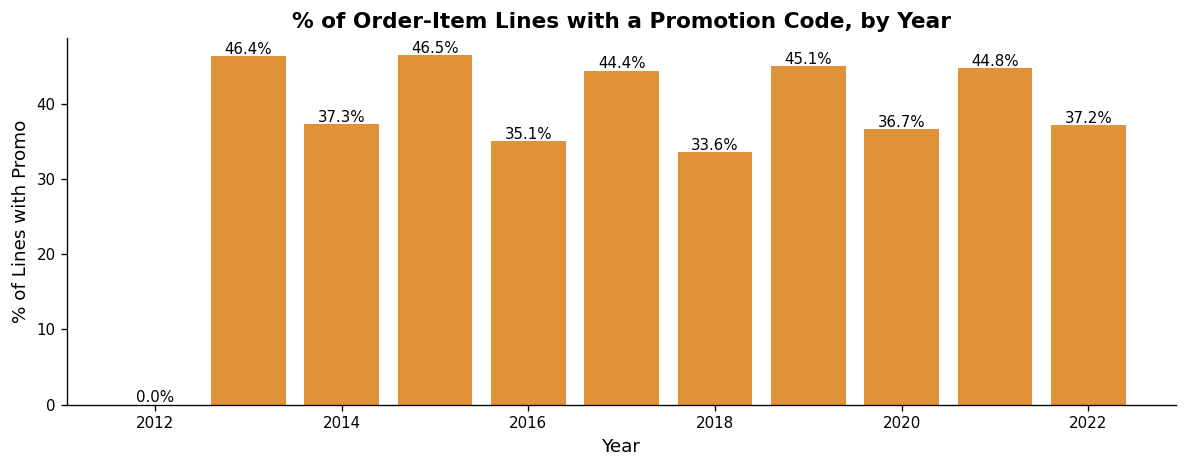

In [24]:
# ── Chart D2: % order-item lines with a promo by year ─────────────────────────
orders_dated = orders[['order_id','order_date']].copy()
oi_dated = order_items.merge(orders_dated, on='order_id', how='left')
oi_dated['year'] = oi_dated['order_date'].dt.year
oi_dated['has_promo'] = oi_dated['promo_id'].notna()

promo_by_year = oi_dated.groupby('year')['has_promo'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(promo_by_year.index, promo_by_year.values, color=PALETTE[3], alpha=0.8)
ax.set_title('% of Order-Item Lines with a Promotion Code, by Year')
ax.set_ylabel('% of Lines with Promo')
ax.set_xlabel('Year')
for yr, val in promo_by_year.items():
    ax.text(yr, val + 0.3, f'{val:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### E. Operations

In [25]:
# Enrich orders with geography
orders_geo = orders.merge(geography[['zip','region']], on='zip', how='left')

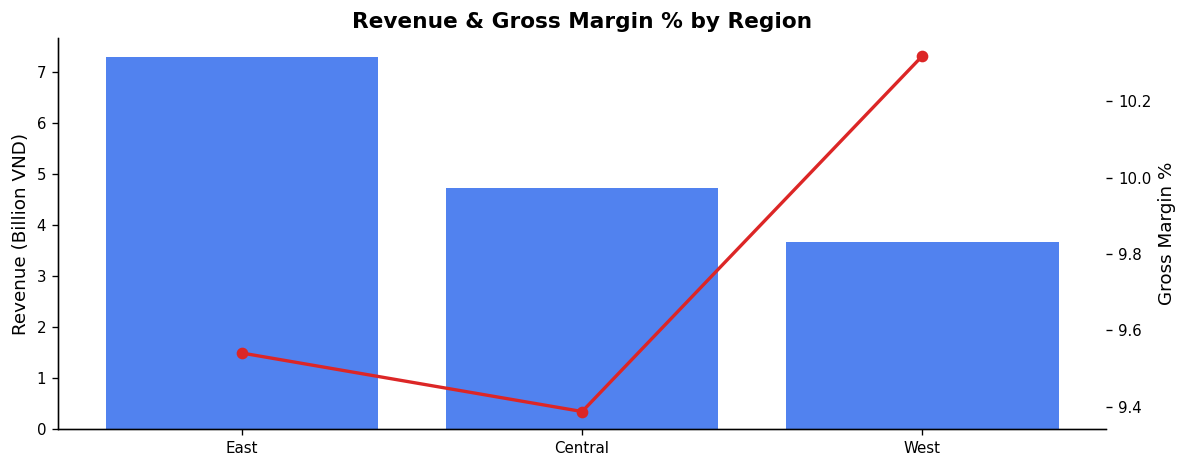

              revenue        profit  margin
region                                     
East     7.291151e+09  6.956483e+08    9.54
Central  4.719491e+09  4.430609e+08    9.39
West     3.670227e+09  3.787095e+08   10.32


In [26]:
# ── Chart E1: Revenue by region ───────────────────────────────────────────────
# Approximate: count orders per region, then scale by average order value
# Better: join to order_items revenue
oi_region = oi_rich.merge(orders[['order_id','zip']], on='order_id', how='left') \
                   .merge(geography[['zip','region']], on='zip', how='left')

region_rev = oi_region.groupby('region')['line_revenue'].sum().sort_values(ascending=False)
region_margin = oi_region.groupby('region').apply(
    lambda g: (g['line_revenue'].sum() - g['line_profit'].mul(-1).add(g['line_revenue']).sum())
    / g['line_revenue'].sum() * 100
)

# Simpler margin calc
region_stats = oi_region.groupby('region').agg(
    revenue=('line_revenue','sum'),
    profit=('line_profit','sum')
).assign(margin=lambda x: x['profit']/x['revenue']*100).sort_values('revenue', ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
x = range(len(region_stats))
ax1.bar(x, region_stats['revenue'] / 1e9, color=PALETTE[0], alpha=0.8)
ax2.plot(x, region_stats['margin'], 'o-', color=PALETTE[2], lw=2)
ax1.set_xticks(list(x))
ax1.set_xticklabels(region_stats.index)
ax1.set_title('Revenue & Gross Margin % by Region')
ax1.set_ylabel('Revenue (Billion VND)')
ax2.set_ylabel('Gross Margin %')
plt.tight_layout()
plt.show()
print(region_stats.round(2))

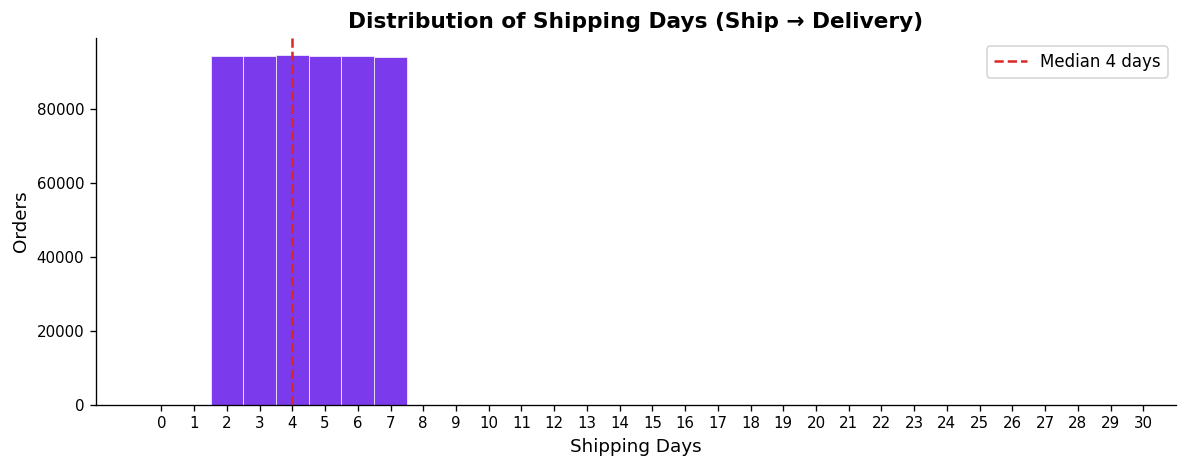

count    566067.00
mean          4.50
std           1.71
min           2.00
25%           3.00
50%           4.00
75%           6.00
max           7.00
Name: shipping_days, dtype: float64


In [27]:
# ── Chart E2: Shipping days distribution ──────────────────────────────────────
shipments['shipping_days'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days
valid_ship = shipments[shipments['shipping_days'].between(0, 30)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(valid_ship['shipping_days'], bins=range(0, 31), color=PALETTE[4],
        edgecolor='white', lw=0.4, align='left')
ax.axvline(valid_ship['shipping_days'].median(), color=PALETTE[2],
           linestyle='--', label=f'Median {valid_ship["shipping_days"].median():.0f} days')
ax.set_title('Distribution of Shipping Days (Ship → Delivery)')
ax.set_xlabel('Shipping Days')
ax.set_ylabel('Orders')
ax.set_xticks(range(0, 31))
ax.legend()
plt.tight_layout()
plt.show()
print(valid_ship['shipping_days'].describe().round(2))

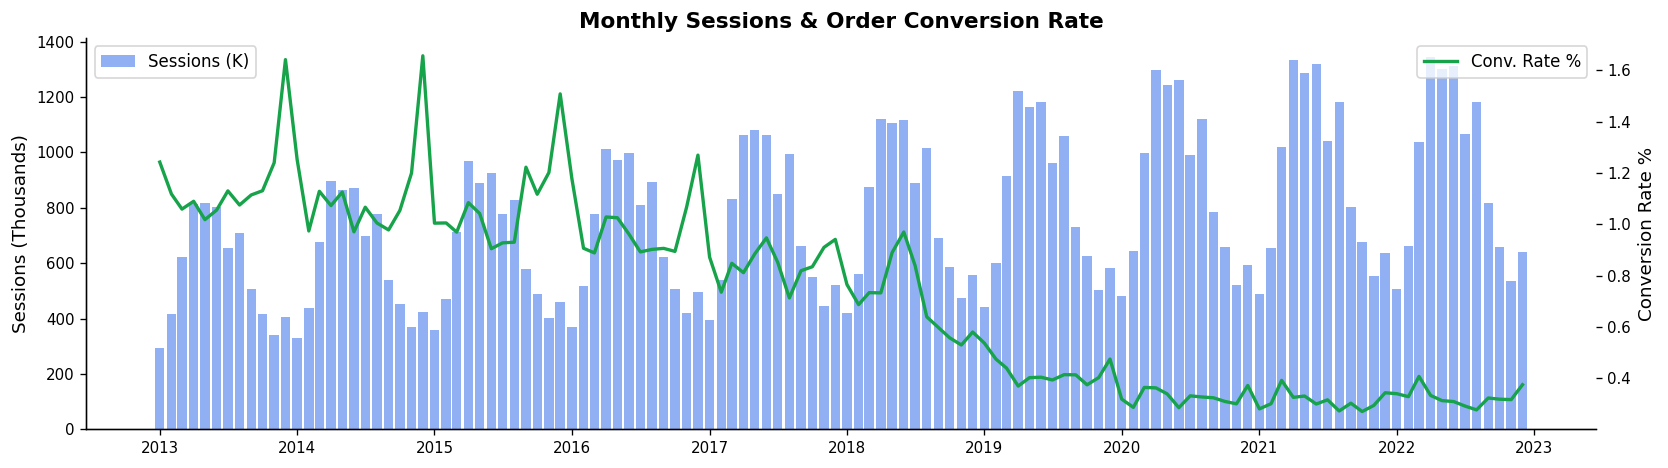

In [28]:
# ── Chart E3: Monthly conversion rate ─────────────────────────────────────────
web_traffic['month'] = web_traffic['date'].dt.to_period('M').dt.to_timestamp()
monthly_web = web_traffic.groupby('month').agg(
    sessions=('sessions', 'sum'),
    conversion_rate=('sessions', lambda x: None)  # placeholder
).drop(columns='conversion_rate')

# Compute conversion as orders/sessions
monthly_orders = orders.copy()
monthly_orders['month'] = monthly_orders['order_date'].dt.to_period('M').dt.to_timestamp()
orders_pm = monthly_orders.groupby('month')['order_id'].count().rename('orders')
monthly_web = monthly_web.join(orders_pm)
monthly_web['conv_rate'] = monthly_web['orders'] / monthly_web['sessions'] * 100

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.bar(monthly_web.index, monthly_web['sessions'] / 1e3, width=25,
        color=PALETTE[0], alpha=0.5, label='Sessions (K)')
ax2.plot(monthly_web.index, monthly_web['conv_rate'], color=PALETTE[1],
         lw=2, label='Conv. Rate %')
ax1.set_title('Monthly Sessions & Order Conversion Rate')
ax1.set_ylabel('Sessions (Thousands)')
ax2.set_ylabel('Conversion Rate %')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

### F. Quality & Customer Experience

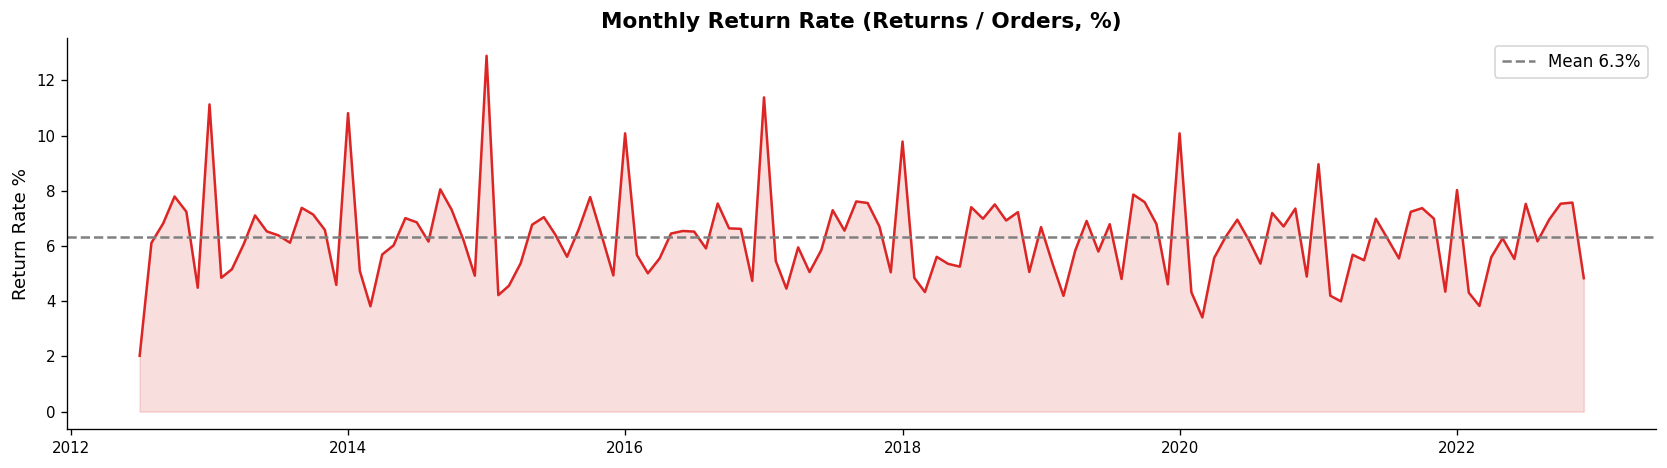

In [29]:
# ── Chart F1: Monthly return rate ─────────────────────────────────────────────
returns['month'] = returns['return_date'].dt.to_period('M').dt.to_timestamp()
monthly_returns = returns.groupby('month')['return_id'].count().rename('returns')

orders_monthly = orders.copy()
orders_monthly['month'] = orders_monthly['order_date'].dt.to_period('M').dt.to_timestamp()
monthly_orders_count = orders_monthly.groupby('month')['order_id'].count().rename('orders')

return_rate = (monthly_returns / monthly_orders_count * 100).dropna()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(return_rate.index, return_rate.values, color=PALETTE[2], lw=1.5)
ax.fill_between(return_rate.index, return_rate.values, alpha=0.15, color=PALETTE[2])
ax.set_title('Monthly Return Rate (Returns / Orders, %)')
ax.set_ylabel('Return Rate %')
ax.axhline(return_rate.mean(), linestyle='--', color='gray',
           label=f'Mean {return_rate.mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

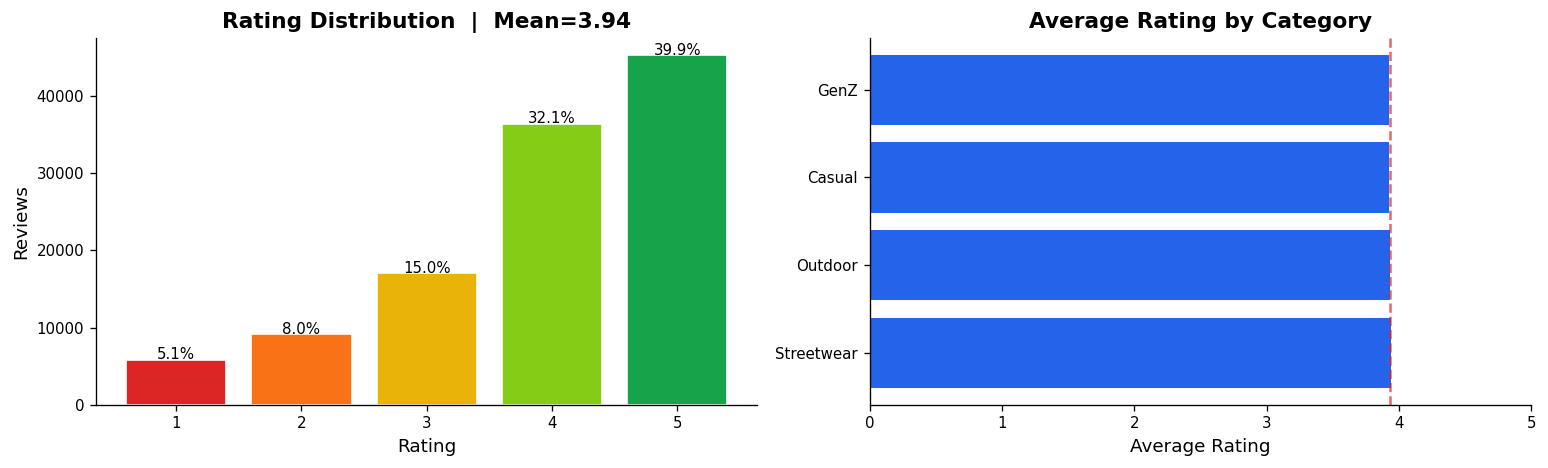

In [30]:
# ── Chart F2: Rating distribution ─────────────────────────────────────────────
rating_counts = reviews['rating'].value_counts().sort_index()
colors_rating = ['#dc2626', '#f97316', '#eab308', '#84cc16', '#16a34a']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(rating_counts.index, rating_counts.values,
            color=colors_rating, edgecolor='white')
axes[0].set_title(f'Rating Distribution  |  Mean={reviews["rating"].mean():.2f}')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Reviews')
for r, c in zip(rating_counts.index, rating_counts.values):
    axes[0].text(r, c + 100, f'{c/len(reviews)*100:.1f}%', ha='center', fontsize=9)

# Rating by category
rev_cat = reviews.merge(order_items[['order_id','product_id']].drop_duplicates(),
                        on=['order_id','product_id'], how='left') \
                 .merge(products[['product_id','category']], on='product_id', how='left')
cat_rating = rev_cat.groupby('category')['rating'].mean().sort_values(ascending=False)
axes[1].barh(cat_rating.index, cat_rating.values, color=PALETTE[0])
axes[1].set_title('Average Rating by Category')
axes[1].set_xlabel('Average Rating')
axes[1].set_xlim(0, 5)
axes[1].axvline(reviews['rating'].mean(), color=PALETTE[2], linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

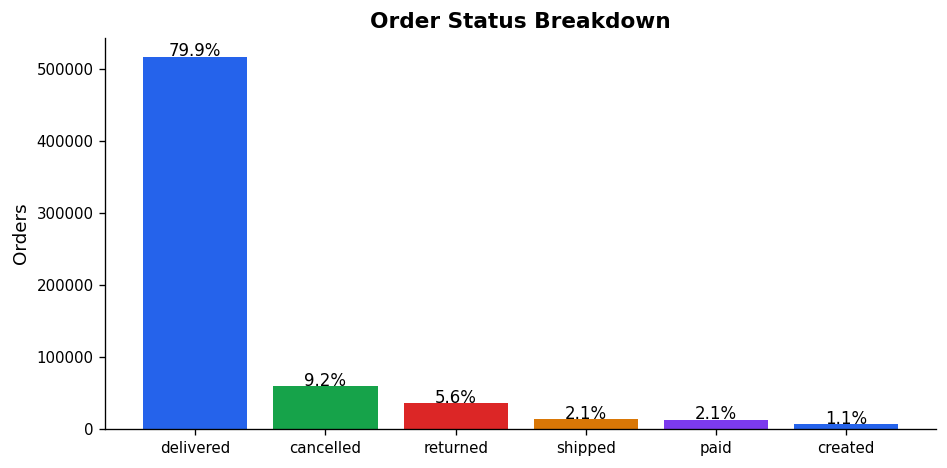

order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: count, dtype: int64


In [31]:
# ── Chart F3: Order status breakdown ──────────────────────────────────────────
status_counts = orders['order_status'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(status_counts.index, status_counts.values, color=PALETTE[:len(status_counts)])
ax.set_title('Order Status Breakdown')
ax.set_ylabel('Orders')
for bar, count in zip(bars, status_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count/len(orders)*100:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print(status_counts)

### G. Inventory
#### G1. Monthly Avg Stock-on-Hand vs Units Sold

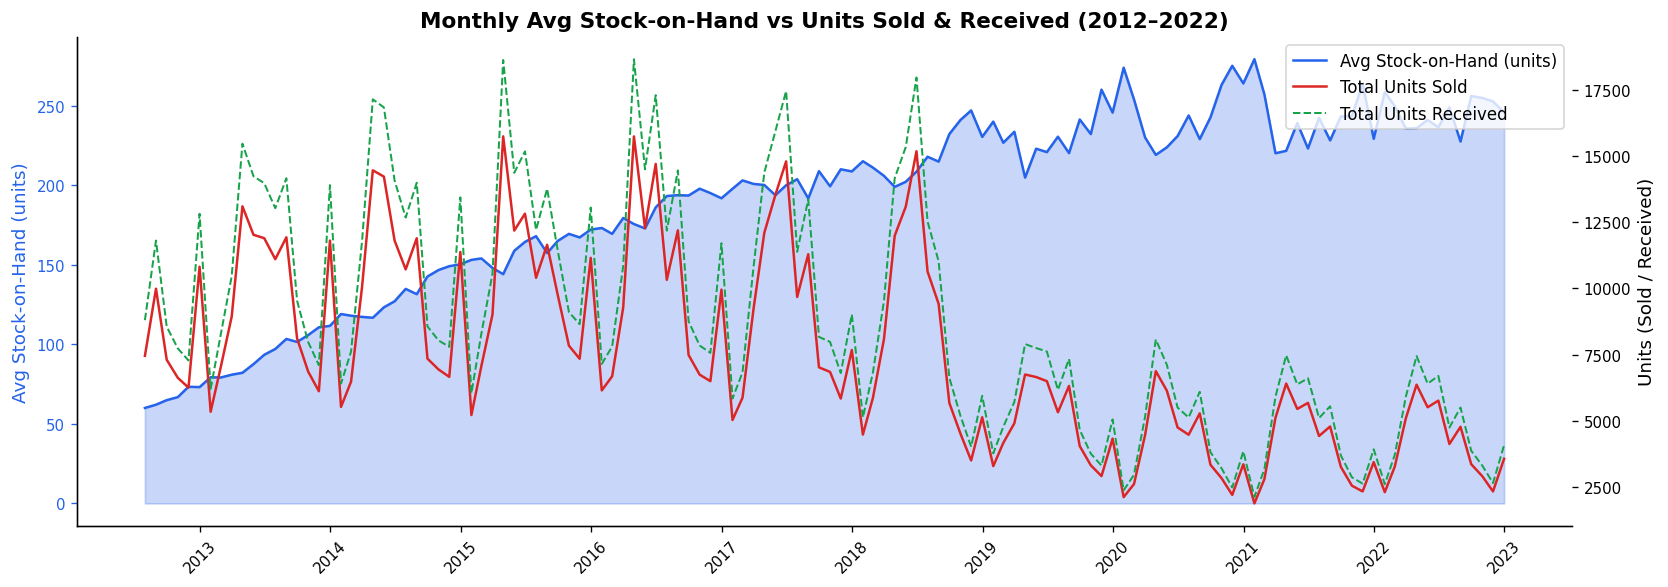

       avg_stock  total_sold  total_received
count      126.0       126.0           126.0
mean       189.4      7372.0          8629.1
std         57.3      3567.7          4260.8
min         60.0      1882.0          2129.0
25%        151.0      4753.2          5496.8
50%        202.6      6636.0          7738.0
75%        233.3     10255.8         12081.8
max        279.3     15731.0         18644.0


In [32]:
# ── Chart G1: Monthly avg Stock-on-Hand vs Units Sold (2012–2022) ────────────
inv_monthly = (
    inventory
    .groupby('snapshot_date', as_index=False)
    .agg(
        avg_stock=('stock_on_hand', 'mean'),
        total_sold=('units_sold', 'sum'),
        total_received=('units_received', 'sum'),
    )
    .sort_values('snapshot_date')
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.fill_between(inv_monthly['snapshot_date'], inv_monthly['avg_stock'],
                 alpha=0.25, color=PALETTE[0])
ax1.plot(inv_monthly['snapshot_date'], inv_monthly['avg_stock'],
         color=PALETTE[0], lw=1.5, label='Avg Stock-on-Hand (units)')

ax2.plot(inv_monthly['snapshot_date'], inv_monthly['total_sold'],
         color=PALETTE[2], lw=1.5, label='Total Units Sold')
ax2.plot(inv_monthly['snapshot_date'], inv_monthly['total_received'],
         color=PALETTE[1], lw=1.2, linestyle='--', label='Total Units Received')

ax1.set_title('Monthly Avg Stock-on-Hand vs Units Sold & Received (2012–2022)')
ax1.set_ylabel('Avg Stock-on-Hand (units)', color=PALETTE[0])
ax2.set_ylabel('Units (Sold / Received)', color='black')
ax1.tick_params(axis='y', colors=PALETTE[0])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

import matplotlib.dates as mdates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
plt.show()

print(inv_monthly[['snapshot_date','avg_stock','total_sold','total_received']]
      .set_index('snapshot_date').describe().round(1).to_string())

---
## Step 1.4 — Surprising Observations

> *Record anything unexpected from the quick EDA above. These become hypothesis seeds in Phase 2.*

In [33]:
# ── Summary: Key numbers to inform observations ───────────────────────────────
print('=== REVENUE & MARGIN ===')
print(annual_rev[['Revenue','Margin%','YoY_Rev%']].round(2).to_string())

print('\n=== PROMO PENETRATION BY YEAR ===')
print(promo_by_year.round(1).to_string())

print('\n=== RETURN RATE STATS ===')
print(f'Mean monthly return rate: {return_rate.mean():.1f}%')
print(f'Max monthly return rate : {return_rate.max():.1f}% in {return_rate.idxmax().strftime("%Y-%m")}')

print('\n=== TOP RETURN REASONS ===')
print(returns['return_reason'].value_counts().head(5))

print('\n=== CATEGORY STATS ===')
print(cat_stats.round(2).to_string())

print('\n=== REGION STATS ===')
print(region_stats.round(2).to_string())

print('\n=== PAYMENT METHOD DISTRIBUTION ===')
print(orders['payment_method'].value_counts())

=== REVENUE & MARGIN ===
           Revenue  Margin%  YoY_Rev%
Date                                 
2012  7.414977e+08    20.77       NaN
2013  1.657169e+09    11.54    123.49
2014  1.871846e+09    15.88     12.95
2015  1.889934e+09    11.88      0.97
2016  2.104641e+09    15.40     11.36
2017  1.911164e+09    11.34     -9.19
2018  1.850122e+09    16.64     -3.19
2019  1.136801e+09    11.58    -38.56
2020  1.054512e+09    15.97     -7.24
2021  1.043040e+09     9.77     -1.09
2022  1.169749e+09    12.77     12.15

=== PROMO PENETRATION BY YEAR ===
year
2012     0.0
2013    46.4
2014    37.3
2015    46.5
2016    35.1
2017    44.4
2018    33.6
2019    45.1
2020    36.7
2021    44.8
2022    37.2

=== RETURN RATE STATS ===
Mean monthly return rate: 6.3%
Max monthly return rate : 12.9% in 2015-01

=== TOP RETURN REASONS ===
return_reason
wrong_size          13967
defective            8020
not_as_described     7035
changed_mind         6931
late_delivery        3986
Name: count, dtype: int64

In [34]:
# ── Return rate by category ────────────────────────────────────────────────────
returns_cat = returns.merge(order_items[['order_id','product_id']].drop_duplicates(),
                            on=['order_id','product_id'], how='left') \
                     .merge(products[['product_id','category','segment']], on='product_id', how='left')

orders_per_cat = oi_rich.groupby('category')['order_id'].nunique()
returns_per_cat = returns_cat.groupby('category')['return_id'].count()
ret_rate_cat = (returns_per_cat / orders_per_cat * 100).sort_values(ascending=False)
print('Return rate by category (%):')
print(ret_rate_cat.round(1))

# Return rate by size
ret_size = returns.merge(order_items[['order_id','product_id']].drop_duplicates(),
                         on=['order_id','product_id'], how='left') \
                  .merge(products[['product_id','size']], on='product_id', how='left')

orders_per_size = oi_rich.merge(products[['product_id','size']], on='product_id', how='left') \
                         .groupby('size')['order_id'].nunique()
returns_per_size = ret_size.groupby('size')['return_id'].count()
ret_rate_size = (returns_per_size / orders_per_size * 100).sort_values(ascending=False)
print('\nReturn rate by size (%):')
print(ret_rate_size.round(1))

Return rate by category (%):
category
Outdoor       7.3
GenZ          5.7
Streetwear    5.6
Casual        5.5
dtype: float64

Return rate by size (%):
size
S     5.7
L     5.6
M     5.6
XL    5.5
dtype: float64


In [35]:
# ── COD cancellation check ─────────────────────────────────────────────────────
cancel_by_payment = orders.groupby('payment_method')['order_status'].apply(
    lambda x: (x == 'cancelled').mean() * 100
).rename('cancel_rate_%').round(2)
print('Cancellation rate by payment method (%):')
print(cancel_by_payment.sort_values(ascending=False))

Cancellation rate by payment method (%):
payment_method
cod              16.00
paypal            8.06
apple_pay         8.01
credit_card       7.98
bank_transfer     7.89
Name: cancel_rate_%, dtype: float64


---
### Observations

> *Surprising or non-obvious findings from the quick EDA — raw material for Phase 2 hypotheses.*

**1. Revenue is in long-term decline, not growth.**
Revenue peaked at ≈2.10B VND in 2016 and has contracted every year since, reaching 1.17B in 2022 — a −44% drop from peak. The 2019 collapse (−38.6% YoY) is especially severe. This inverts the typical growth-stage framing; the real story is **turnaround / triage**.

**2. Gross margins are thin (10–17%) and volatile — no compression trend.**
2021 was the worst year at 9.8%. Margins oscillate without a clear direction, suggesting the problem is **mix shift** (which categories dominate sales) rather than systematic discount creep.

**3. Promo penetration alternates in a biennial pattern (~45% odd years, ~35% even years).**
Promos were 0% in 2012, then 46%→37%→47%→35%... The oscillation is *inversely* correlated with revenue — suggesting promotions are deployed as a reactive stimulus, not a growth driver.

**4. COD cancellation rate is 2× all other payment methods (16% vs ~8%).**
Confirms hypothesis H6. With ~87.5% shipment coverage and COD being popular in Vietnam, failed COD deliveries represent significant sunk logistics cost.

**5. "Wrong size" is #1 return reason (35% of all returns), but all sizes have nearly identical return rates (~5.5–5.7%).**
The size problem is *uniform*, not XL-specific. Likely a systemic sizing accuracy issue across the entire catalogue.

**6. `promo_id_2` is 100% null — Task D3 (stackable promotions) is not analyzable. Skip.**

**7. Streetwear dominates revenue (≈78% of total) but has the lowest margin (9.3%).**
GenZ has the highest margin (15.5%) but the smallest revenue base. A deliberate mix-shift toward GenZ/Outdoor could lift overall margin without touching prices.

**8. 87.5% of orders have a shipment record; only 17.2% have a review.**
Review data is too sparse for reliable sentiment analysis by sub-segment.

**9. 24.8% one-time buyers; 75.2% repeat buyers — retention is healthy.**
Customer attrition is unlikely to be the root cause of revenue decline.

**10. Return rate spiked to 12.9% in January 2015 (mean is 6.3%).**
Post-holiday anomaly or a specific product batch — worth a targeted look.

---
**Top 3 hypothesis seeds for Phase 2:**
- **H_A:** Revenue collapse post-2016 is driven by a structural demand decline in Streetwear — mix shift to GenZ/Outdoor is the recovery path
- **H_B:** COD policy is destroying margin silently — a deposit or verification requirement could recover ~4–8% of cancelled order value
- **H_C:** Promo strategy is reactive (stimulus after bad months) rather than strategic — promos may be training customers to wait for deals

→ Take into **Phase 2 (`02_hypothesis.ipynb`)**.